In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("ipl_data.csv")

In [ ]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


In [ ]:
df.shape

(577, 18)

In [ ]:
df.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               577 non-null    int64  
 1   season           577 non-null    int64  
 2   city             570 non-null    str    
 3   date             577 non-null    str    
 4   team1            577 non-null    str    
 5   team2            577 non-null    str    
 6   toss_winner      577 non-null    str    
 7   toss_decision    577 non-null    str    
 8   result           577 non-null    str    
 9   dl_applied       577 non-null    int64  
 10  winner           574 non-null    str    
 11  win_by_runs      577 non-null    int64  
 12  win_by_wickets   577 non-null    int64  
 13  player_of_match  574 non-null    str    
 14  venue            577 non-null    str    
 15  umpire1          577 non-null    str    
 16  umpire2          577 non-null    str    
 17  umpire3          0 non-null

In [ ]:
df.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              0
umpire2              0
umpire3            577
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

***Drop useless column***

In [ ]:
df.drop(columns='umpire3', inplace=True)

***Convert date column***

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               577 non-null    int64         
 1   season           577 non-null    int64         
 2   city             570 non-null    str           
 3   date             577 non-null    datetime64[us]
 4   team1            577 non-null    str           
 5   team2            577 non-null    str           
 6   toss_winner      577 non-null    str           
 7   toss_decision    577 non-null    str           
 8   result           577 non-null    str           
 9   dl_applied       577 non-null    int64         
 10  winner           574 non-null    str           
 11  win_by_runs      577 non-null    int64         
 12  win_by_wickets   577 non-null    int64         
 13  player_of_match  574 non-null    str           
 14  venue            577 non-null    str           
 15  

In [ ]:
df.describe()

,id,season,date,dl_applied,win_by_runs,win_by_wickets
count,577.000000,577.000000,577,577.000000,577.000000,577.000000
mean,289.000000,2012.029463,2012-05-09 17:23:11.334488,0.025997,13.715771,3.363951
min,1.000000,2008.000000,2008-04-18 00:00:00,0.000000,0.000000,0.000000
25%,145.000000,2010.000000,2010-04-01 00:00:00,0.000000,0.000000,0.000000
50%,289.000000,2012.000000,2012-05-01 00:00:00,0.000000,0.000000,3.000000
75%,433.000000,2014.000000,2014-05-11 00:00:00,0.000000,20.000000,6.000000
max,577.000000,2016.000000,2016-05-29 00:00:00,1.000000,144.000000,10.000000
std,166.709828,2.486247,NaN,0.159263,23.619282,3.416049


In [ ]:
matches_per_season = df['season'].value_counts().sort_index()

In [ ]:
matches_per_season

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
Name: count, dtype: int64

<Axes: xlabel='season'>

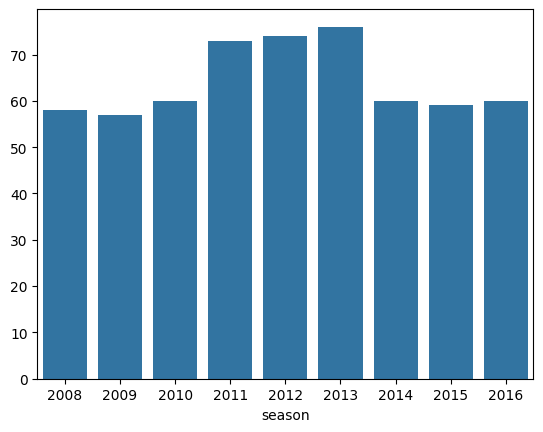

In [ ]:
sns.barplot(
    x=matches_per_season.index,
    y=matches_per_season.values
)

In [ ]:
df[df['winner'].isnull()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
241,242,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker
486,487,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak
511,512,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan


The missing values in winner and player_of_match correspond to matches that ended with "No Result". Therefore, these missing values are meaningful and should not be imputed or removed.

In [ ]:
df[df['city'].isnull()][['season','venue']]

,season,venue
402,2014,Dubai International Cricket Stadium
403,2014,Dubai International Cricket Stadium
407,2014,Dubai International Cricket Stadium
409,2014,Dubai International Cricket Stadium
410,2014,Dubai International Cricket Stadium
415,2014,Dubai International Cricket Stadium
417,2014,Dubai International Cricket Stadium


In [ ]:
team_wins = df['winner'].value_counts()

team_wins

winner
Mumbai Indians                 80
Chennai Super Kings            79
Royal Challengers Bangalore    70
Kolkata Knight Riders          68
Rajasthan Royals               63
Kings XI Punjab                63
Delhi Daredevils               56
Sunrisers Hyderabad            34
Deccan Chargers                29
Pune Warriors                  12
Gujarat Lions                   9
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
Name: count, dtype: int64

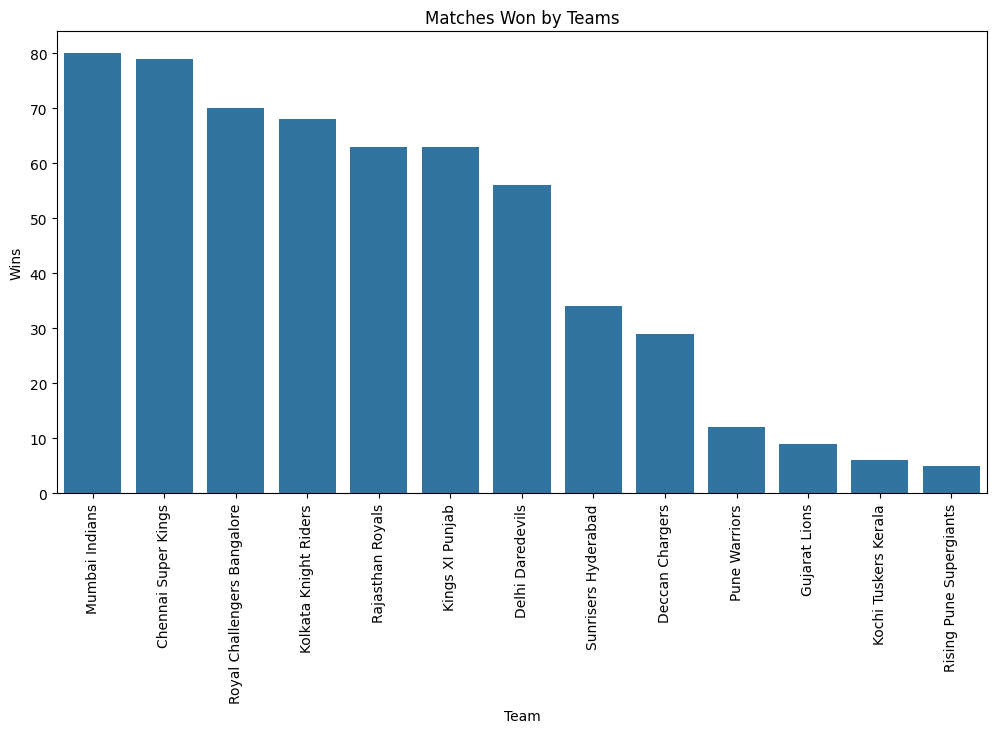

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=team_wins.index,
    y=team_wins.values
)

plt.xticks(rotation=90)
plt.title("Matches Won by Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()

In [ ]:
print(team_wins.head(10))

winner
Mumbai Indians                 80
Chennai Super Kings            79
Royal Challengers Bangalore    70
Kolkata Knight Riders          68
Rajasthan Royals               63
Kings XI Punjab                63
Delhi Daredevils               56
Sunrisers Hyderabad            34
Deccan Chargers                29
Pune Warriors                  12
Name: count, dtype: int64


In [ ]:
toss_decision_counts = df['toss_decision'].value_counts()
toss_decision_counts

toss_decision
field    315
bat      262
Name: count, dtype: int64

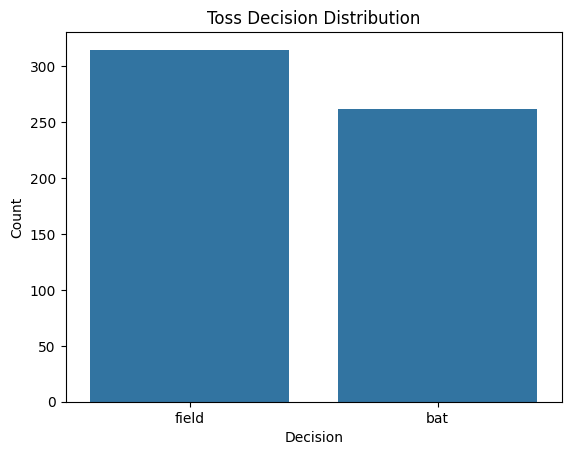

In [ ]:
sns.countplot(data=df, x='toss_decision')

plt.title("Toss Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

In [ ]:
pd.crosstab(
    df['toss_decision'],
    df['winner'].notnull()
)

winner,False,True
toss_decision,,
bat,1,261
field,2,313


In [ ]:
toss_match_win = (df['toss_winner'] == df['winner']).sum()
total_matches = df['winner'].notna().sum()
print(toss_match_win)
print(total_matches)
print("Win Percentage:",
      round((toss_match_win/total_matches)*100,2))


291
574
Win Percentage: 50.7


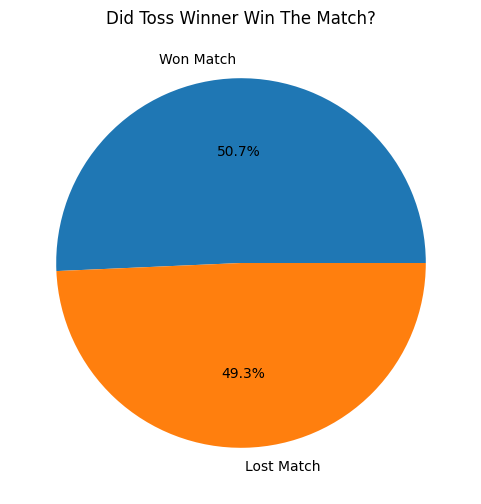

In [ ]:
labels = ['Won Match', 'Lost Match']
values = [
    toss_match_win,
    total_matches - toss_match_win
]

plt.figure(figsize=(6,6))
plt.pie(values,
        labels=labels,
        autopct='%1.1f%%')

plt.title("Did Toss Winner Win The Match?")
plt.show()

toss_winner
Mumbai Indians                 74
Kolkata Knight Riders          69
Chennai Super Kings            66
Kings XI Punjab                64
Delhi Daredevils               64
Rajasthan Royals               63
Royal Challengers Bangalore    61
Deccan Chargers                43
Sunrisers Hyderabad            30
Pune Warriors                  20
Kochi Tuskers Kerala            8
Gujarat Lions                   8
Rising Pune Supergiants         7
Name: count, dtype: int64


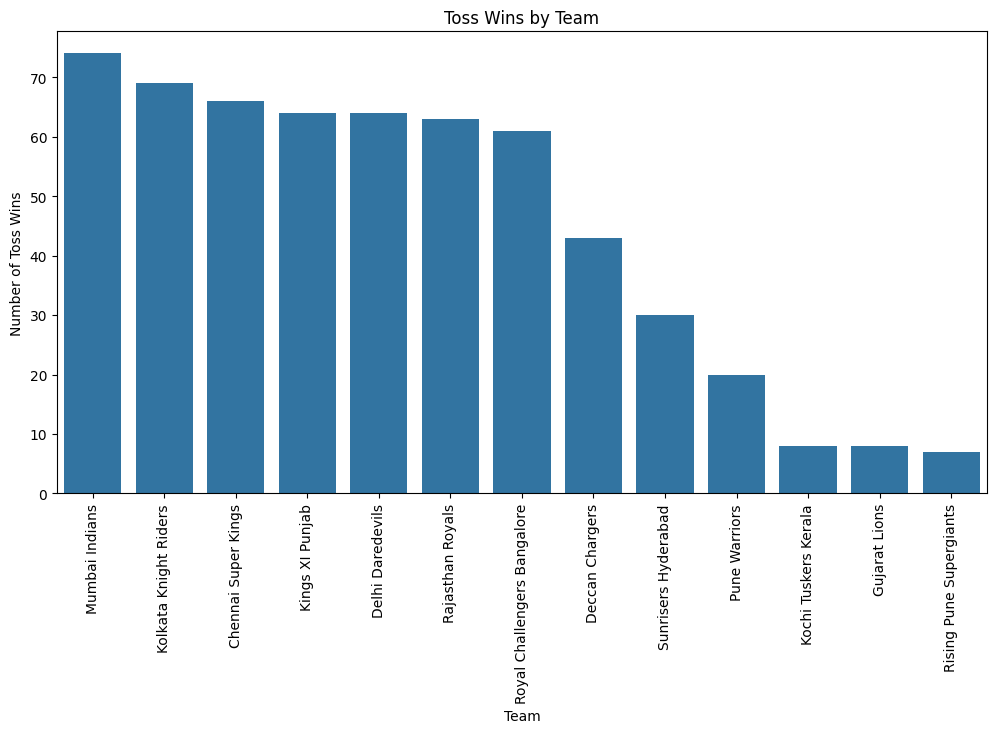

In [ ]:
toss_wins = df['toss_winner'].value_counts()

print(toss_wins)

plt.figure(figsize=(12,6))
sns.barplot(
    x=toss_wins.index,
    y=toss_wins.values
)

plt.xticks(rotation=90)
plt.title("Toss Wins by Team")
plt.xlabel("Team")
plt.ylabel("Number of Toss Wins")
plt.show()

In [ ]:
pom = df['player_of_match'].value_counts()

print(pom.head(15))

player_of_match
CH Gayle          17
YK Pathan         16
AB de Villiers    15
DA Warner         14
SK Raina          13
RG Sharma         13
MEK Hussey        12
MS Dhoni          12
G Gambhir         12
AM Rahane         12
V Sehwag          11
V Kohli           11
SR Watson         10
JH Kallis         10
DR Smith          10
Name: count, dtype: int64


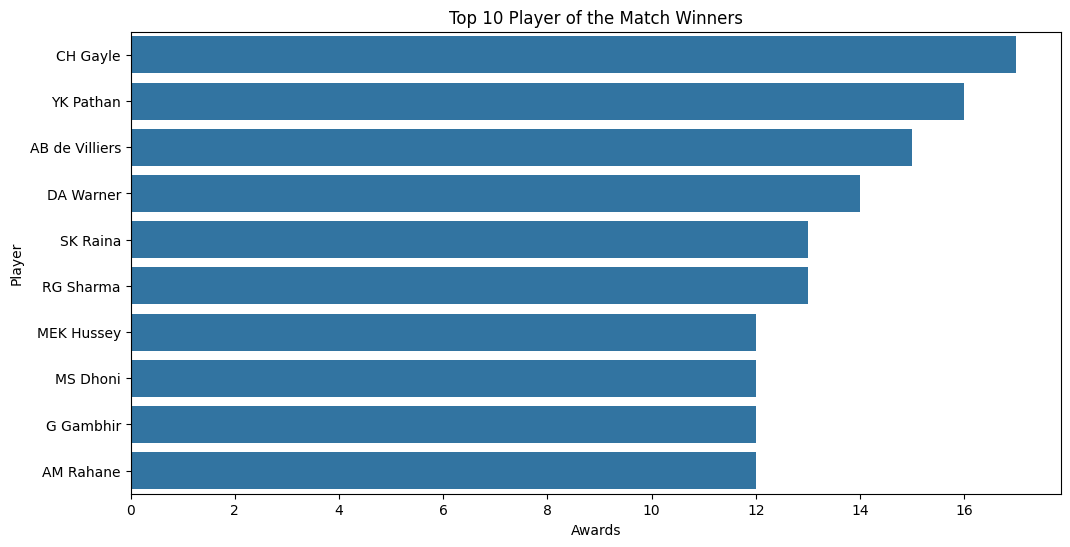

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=pom.head(10).values,
    y=pom.head(10).index
)

plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.show()

In [ ]:
venue_counts = df['venue'].value_counts()

print(venue_counts.head(15))

venue
M Chinnaswamy Stadium                                  58
Eden Gardens                                           54
Feroz Shah Kotla                                       53
Wankhede Stadium                                       49
MA Chidambaram Stadium, Chepauk                        48
Rajiv Gandhi International Stadium, Uppal              41
Punjab Cricket Association Stadium, Mohali             35
Sawai Mansingh Stadium                                 33
Dr DY Patil Sports Academy                             17
Subrata Roy Sahara Stadium                             17
Kingsmead                                              15
SuperSport Park                                        12
Sardar Patel Stadium, Motera                           12
Brabourne Stadium                                      11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11
Name: count, dtype: int64


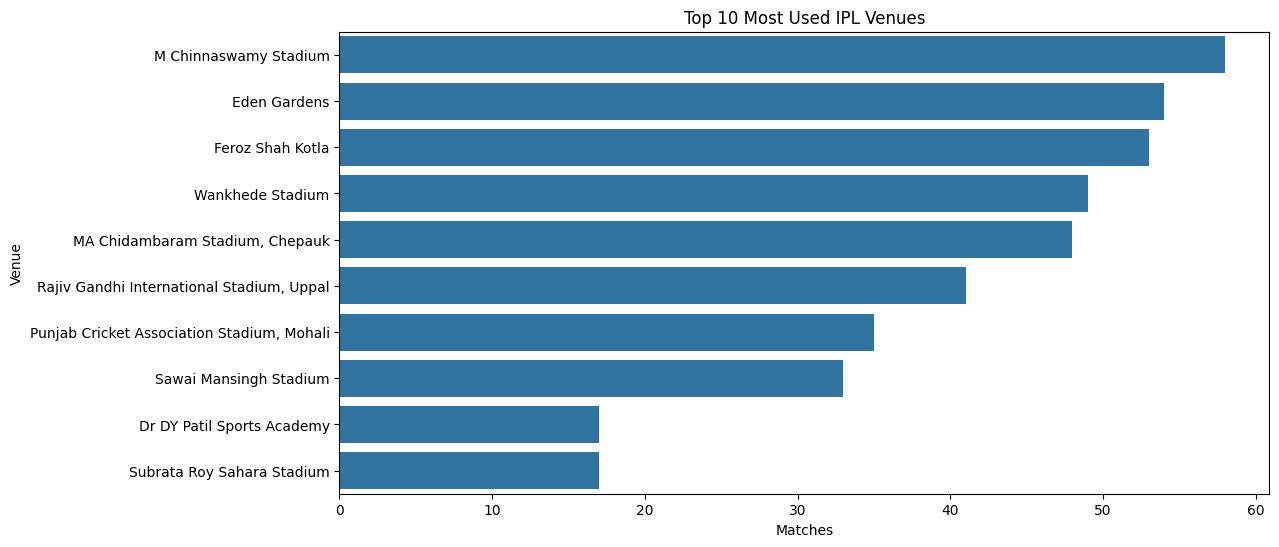

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=venue_counts.head(10).values,
    y=venue_counts.head(10).index
)

plt.title("Top 10 Most Used IPL Venues")
plt.xlabel("Matches")
plt.ylabel("Venue")
plt.show()

In [ ]:
venue_wins = df.groupby('venue')['winner'].count()

print(
    venue_wins.sort_values(
        ascending=False
    ).head(10)
)

venue
M Chinnaswamy Stadium                         56
Eden Gardens                                  54
Feroz Shah Kotla                              52
Wankhede Stadium                              49
MA Chidambaram Stadium, Chepauk               48
Rajiv Gandhi International Stadium, Uppal     41
Punjab Cricket Association Stadium, Mohali    35
Sawai Mansingh Stadium                        33
Dr DY Patil Sports Academy                    17
Subrata Roy Sahara Stadium                    17
Name: winner, dtype: int64


In [ ]:
bat_first_wins = (df['win_by_runs'] > 0).sum()
chasing_wins = (df['win_by_wickets'] > 0).sum()

print("Bat First Wins:", bat_first_wins)
print("Chasing Wins:", chasing_wins)

Bat First Wins: 261
Chasing Wins: 307


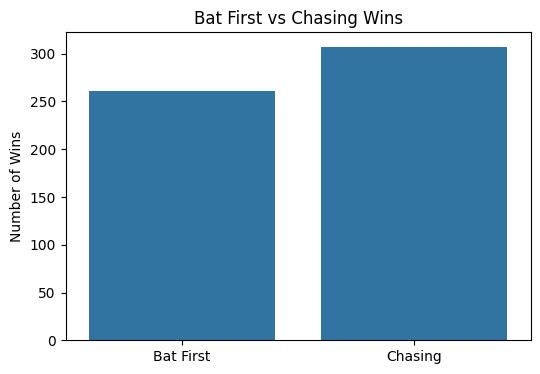

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=['Bat First','Chasing'],
    y=[bat_first_wins, chasing_wins]
)

plt.title("Bat First vs Chasing Wins")
plt.ylabel("Number of Wins")
plt.show()

In [ ]:
print("Highest Run Margin:")
print(df['win_by_runs'].max())

print("\nHighest Wicket Margin:")
print(df['win_by_wickets'].max())

Highest Run Margin:
144

Highest Wicket Margin:
10


In [ ]:
# Biggest run victory
print(
    df.loc[df['win_by_runs'].idxmax(),
           ['winner','win_by_runs','venue','season']]
)

# Biggest wicket victory
print(
    df.loc[df['win_by_wickets'].idxmax(),
           ['winner','win_by_wickets','venue','season']]
)

winner         Royal Challengers Bangalore
win_by_runs                            144
venue                M Chinnaswamy Stadium
season                                2016
Name: 560, dtype: object
winner                       Deccan Chargers
win_by_wickets                            10
venue             Dr DY Patil Sports Academy
season                                  2008
Name: 12, dtype: object


In [ ]:
(team_wins / (df['team1'].value_counts() + df['team2'].value_counts())) * 100

winner
Chennai Super Kings            60.305344
Deccan Chargers                38.666667
Delhi Daredevils               42.105263
Gujarat Lions                  56.250000
Kings XI Punjab                47.014925
Kochi Tuskers Kerala           42.857143
Kolkata Knight Riders          51.515152
Mumbai Indians                 57.142857
Pune Warriors                  26.086957
Rajasthan Royals               53.389831
Rising Pune Supergiants        35.714286
Royal Challengers Bangalore    50.359712
Sunrisers Hyderabad            54.838710
Name: count, dtype: float64

In [ ]:
pd.crosstab(
    df['toss_decision'],
    df['toss_winner'] == df['winner']
)

col_0,False,True
toss_decision,,
bat,144,118
field,142,173


In [ ]:
pd.crosstab(df['venue'], df['winner'])

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
venue,,,,,,,,,,,,,
Barabati Stadium,0,3,0,0,1,0,3,0,0,0,0,0,0
Brabourne Stadium,1,0,0,0,0,0,0,6,0,2,0,1,1
Buffalo Park,1,0,1,0,0,0,0,1,0,0,0,0,0
De Beers Diamond Oval,1,1,0,0,1,0,0,0,0,0,0,0,0
Dr DY Patil Sports Academy,3,2,1,0,0,0,2,5,2,1,0,1,0
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,1,0,1,0,1,0,0,2,0,1,2,0,3
Dubai International Cricket Stadium,2,0,1,0,1,0,0,0,0,0,0,1,2
Eden Gardens,4,0,1,1,2,1,33,8,0,1,0,3,0
Feroz Shah Kotla,5,2,19,1,4,1,4,2,1,4,1,4,4


<Axes: >

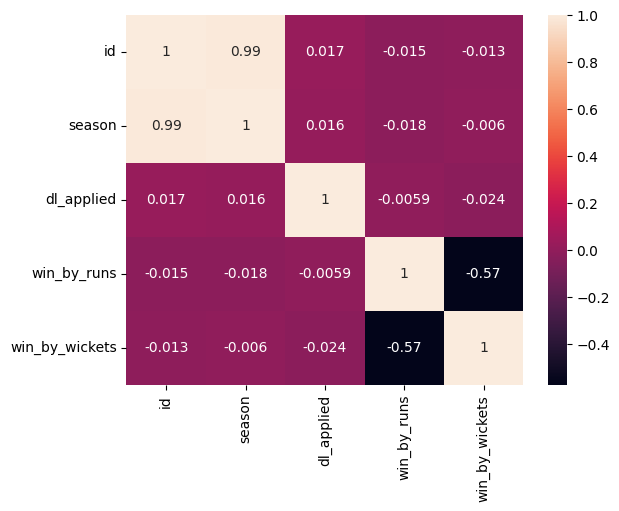

In [ ]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

In [ ]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan
